In [4]:
# ============================================
# HOUSE PRICE PREDICTION PROJECT
# ============================================

# Machine Learning + Deep Learning Project

In [5]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# ============================================
# MACHINE LEARNING LIBRARIES
# ============================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [7]:
# ============================================
# XGBOOST
# ============================================

from xgboost import XGBRegressor

In [8]:
# ============================================
# DEEP LEARNING
# ============================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

In [9]:
# ============================================
# WARNINGS
# ============================================

import warnings

warnings.filterwarnings('ignore')

In [12]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("/Users/apple/code/Datamites Project/House Price Prediction/Data/data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [13]:
  # ============================================
# SHOW DATASET
# ============================================

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
# ============================================
# DATASET SHAPE
# ============================================

print(df.shape)

(1460, 81)


In [15]:
# ============================================
# DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [16]:
# ============================================
# CHECK MISSING VALUES
# ============================================

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [17]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

for col in df.columns:

    # Numerical columns
    if df[col].dtype != 'object':

        df[col] = df[col].fillna(
            df[col].median()
        )

    # Categorical columns
    else:

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

print("Missing Values Handled")

Missing Values Handled


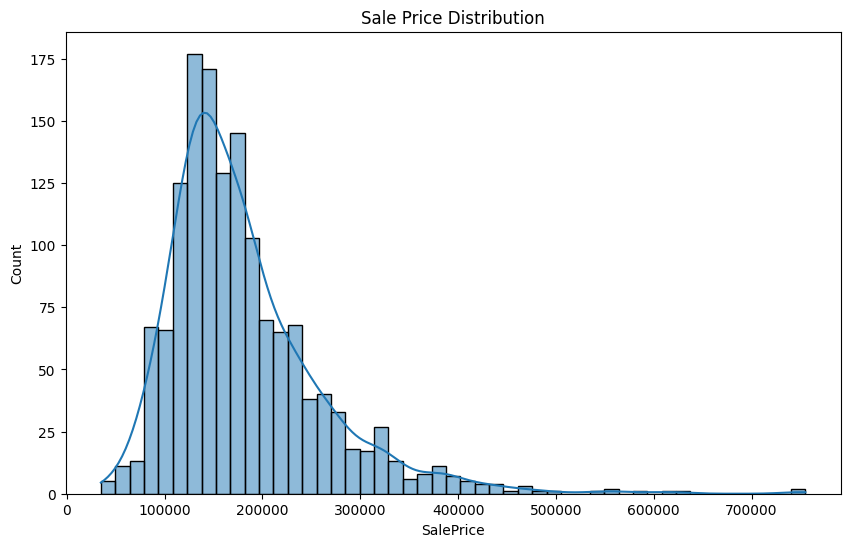

In [18]:
# ============================================
# SALE PRICE DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(df['SalePrice'], kde=True)

plt.title("Sale Price Distribution")

plt.show()

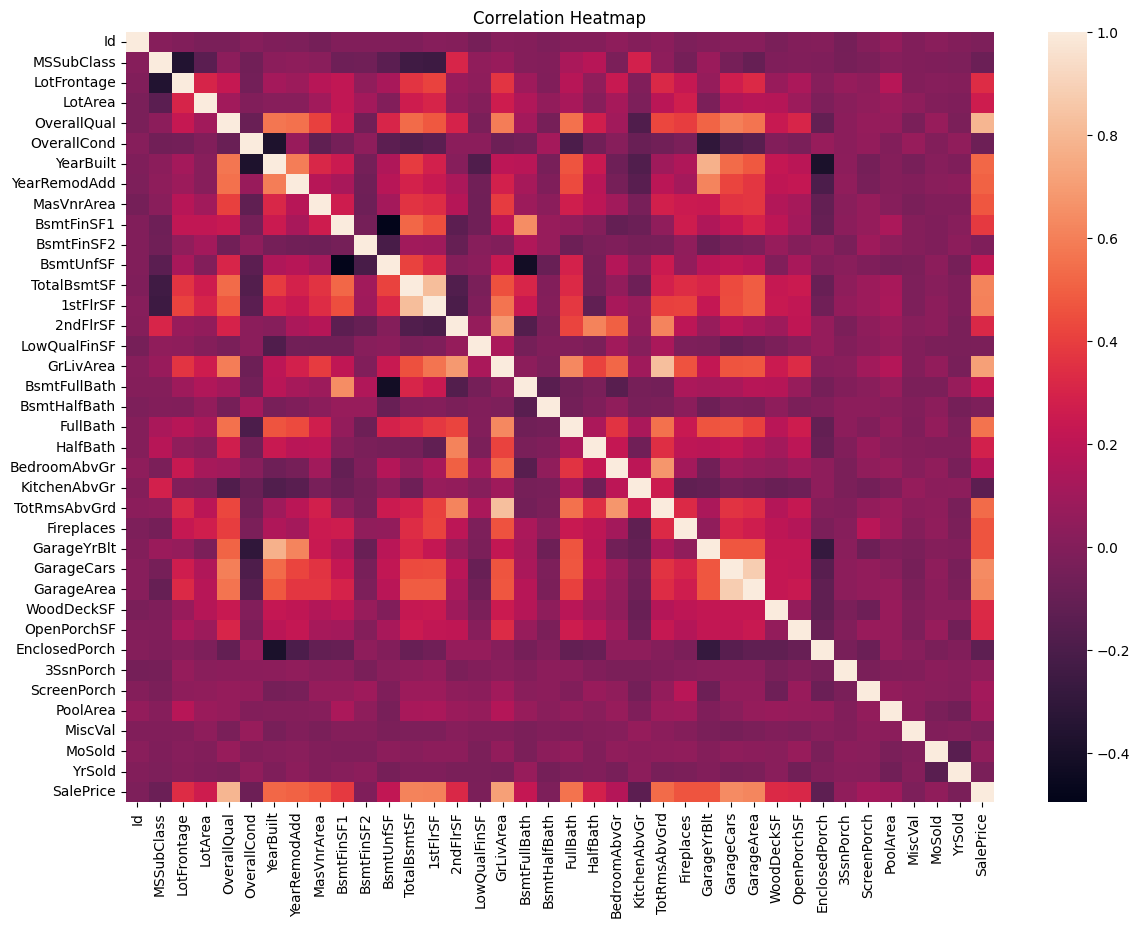

In [19]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(14,10))

numeric_data = df.select_dtypes(include=np.number)

sns.heatmap(numeric_data.corr())

plt.title("Correlation Heatmap")

plt.show()

In [20]:
# ============================================
# FEATURE ENGINEERING
# ============================================

df['HouseAge'] = (
    df['YrSold'] - df['YearBuilt']
)

df['TotalBathrooms'] = (
    df['FullBath']
    + (0.5 * df['HalfBath'])
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [21]:
# ============================================
# LABEL ENCODING
# ============================================

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(
            df[col]
        )

print("Encoding Completed")

Encoding Completed


In [22]:
# ============================================
# FEATURES AND TARGET
# ============================================

X = df.drop('SalePrice', axis=1)

y = df['SalePrice']

print(X.shape)

print(y.shape)

(1460, 82)
(1460,)


In [23]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (1168, 82)
Testing Shape : (292, 82)


In [24]:
# ============================================
# LINEAR REGRESSION
# ============================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Completed")

Linear Regression Completed


In [25]:
# ============================================
# RANDOM FOREST
# ============================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Completed")

Random Forest Completed


In [26]:
# ============================================
# XGBOOST
# ============================================

xgb = XGBRegressor()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Completed")

XGBoost Completed


In [29]:
# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_model(y_test, pred, model_name):

    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    print("\n================================")

    print(model_name)

    print("================================")

    print("MAE :", mae)

    print("MSE :", mse)

    print("RMSE :", rmse)

    print("R2 Score :", r2)

In [28]:
# ============================================
# MODEL EVALUATION
# ============================================

evaluate_model(
    y_test,
    lr_pred,
    "Linear Regression"
)

evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)

evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)


Linear Regression
MAE : 21598.396867592874
MSE : 1249212973.3112123
RMSE : 35344.20706864439
R2 Score : 0.8371369170530589

Random Forest
MAE : 17438.910273972604
MSE : 792403370.5354303
RMSE : 28149.660220603557
R2 Score : 0.89669235060786

XGBoost
MAE : 17429.341796875
MSE : 700607424.0
RMSE : 26468.989856056087
R2 Score : 0.9086599946022034


In [30]:
# ============================================
# Deep Learning Model
# ANN MODEL
# ============================================

ann = Sequential()

ann.add(
    Dense(
        128,
        activation='relu',
        input_dim=X_train.shape[1]
    )
)

ann.add(Dense(64, activation='relu'))

ann.add(Dense(32, activation='relu'))

ann.add(Dense(1))

2026-05-13 14:35:47.794244: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-13 14:35:47.794803: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-13 14:35:47.795358: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-13 14:35:47.795502: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-13 14:35:47.796032: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [31]:
# ============================================
# COMPILE MODEL
# ============================================

ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("ANN Compiled")

ANN Compiled


In [32]:
# ============================================
# TRAIN ANN MODEL
# ============================================

history = ann.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10


2026-05-13 14:37:10.825763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


30/30 [==============================] - ETA: 0s - loss: 31383627776.0000 - mae: 159207.2188  

2026-05-13 14:37:13.993438: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


30/30 [==============================] - 4s 53ms/step - loss: 31383627776.0000 - mae: 159207.2188 - val_loss: 20709597184.0000 - val_mae: 128860.5859
Epoch 2/10
30/30 [==============================] - 0s 6ms/step - loss: 16332945408.0000 - mae: 95620.7812 - val_loss: 7424560128.0000 - val_mae: 64600.0156
Epoch 3/10
30/30 [==============================] - 0s 7ms/step - loss: 11465421824.0000 - mae: 58925.1289 - val_loss: 5131664384.0000 - val_mae: 49551.1484
Epoch 4/10
30/30 [==============================] - 0s 6ms/step - loss: 9474027520.0000 - mae: 54131.3320 - val_loss: 4259471360.0000 - val_mae: 45143.4688
Epoch 5/10
30/30 [==============================] - 0s 6ms/step - loss: 7612313600.0000 - mae: 48483.5312 - val_loss: 3754267648.0000 - val_mae: 42823.6016
Epoch 6/10
30/30 [==============================] - 0s 6ms/step - loss: 6090086400.0000 - mae: 46009.9102 - val_loss: 3204091136.0000 - val_mae: 40455.1406
Epoch 7/10
30/30 [==============================] - 0s 6ms/step - lo

In [33]:
# ============================================
# ANN PREDICTION
# ============================================

ann_pred = ann.predict(X_test)

 1/10 [==>...........................] - ETA: 1s

2026-05-13 14:37:37.484549: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


10/10 [==============================] - 1s 72ms/step


In [34]:
# ============================================
# ANN EVALUATION
# ============================================

evaluate_model(
    y_test,
    ann_pred,
    "ANN Deep Learning"
)


ANN Deep Learning
MAE : 43197.9296875
MSE : 4169044736.0
RMSE : 64568.14025508246
R2 Score : 0.45647096633911133


In [35]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
17,OverallQual,0.556034
46,GrLivArea,0.118601
38,TotalBsmtSF,0.033721
44,2ndFlrSF,0.033615
34,BsmtFinSF1,0.029321
43,1stFlrSF,0.026704
4,LotArea,0.016622
62,GarageArea,0.015947
61,GarageCars,0.011760
12,Neighborhood,0.009298


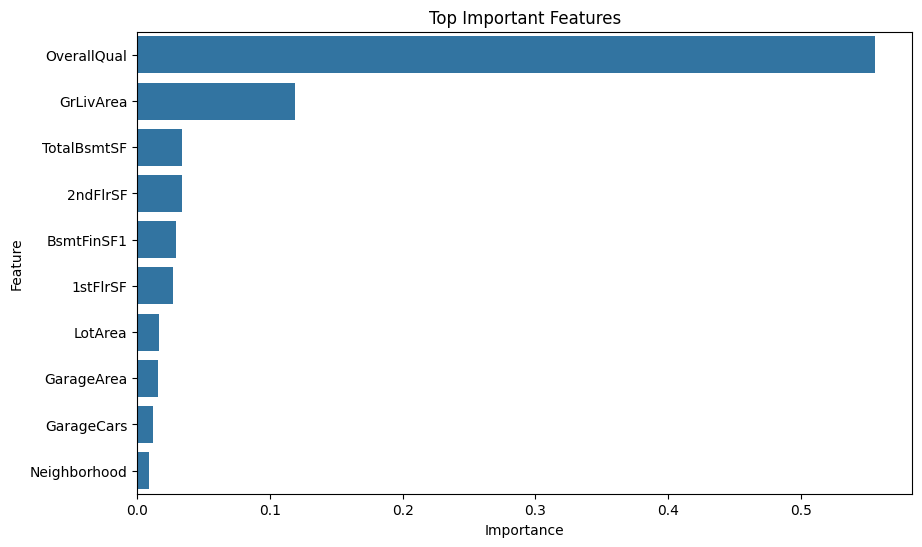

In [36]:
# ============================================
# FEATURE IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance['Importance'][:10],
    y=importance['Feature'][:10]
)

plt.title("Top Important Features")

plt.show()

In [37]:
# ============================================
# SAVE MODEL
# ============================================

import joblib

joblib.dump(
    rf,
    "house_price_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [38]:
# ============================================
# FINAL CONCLUSION
# ============================================

print("""
PROJECT COMPLETED SUCCESSFULLY

Models Used:
1. Linear Regression
2. Random Forest
3. XGBoost
4. ANN Deep Learning

Best Model:
Random Forest / XGBoost
""")


PROJECT COMPLETED SUCCESSFULLY

Models Used:
1. Linear Regression
2. Random Forest
3. XGBoost
4. ANN Deep Learning

Best Model:
Random Forest / XGBoost

